In [1]:
# import os
# import sys

# # 1. Search the entire Kaggle input directory for your specific file
# target_file = 'newaiesdataloader.py'
# found_path = None

# for root, dirs, files in os.walk('/kaggle/input'):
#     if target_file in files:
#         found_path = root
#         break

# if found_path:
#     print(f"🎯 Found dataset folder at: {found_path}")
    
#     # 2. Add that exact folder to Python's path
#     if found_path not in sys.path:
#         sys.path.append(found_path)
    
#     # 3. Now import your classes
#     from newaiesdataloader import CGCD_Master_Dataset, DATA_PATHS
#     print("✅ Data Engine Successfully Imported!")
# else:
#     print(f"❌ Error: Could not find {target_file}. Please check the right sidebar to ensure the dataset is attached.")

In [2]:
import os
import sys
from unittest.mock import MagicMock
import warnings
from collections import Counter
import numpy as np
warnings.filterwarnings("ignore")

# ==============================================================================
# 0. LIGHTNING-FAST DATALOADER IMPORT (FIX FOR THE HANGING ISSUE)
# ==============================================================================
target_file = 'newaiesdataloader.py'
found_path = None

# Fast-Path: Look exactly where Kaggle usually puts it
expected_dir = '/kaggle/input/newaiesdataloader'
if os.path.exists(os.path.join(expected_dir, target_file)):
    found_path = expected_dir
else:
    # Fallback: Search, but IGNORE massive image folders so it doesn't hang
    for root, dirs, files in os.walk('/kaggle/input'):
        # 🛑 The crucial fix: stop searching inside the heavy datasets
        for ignore in ['tiny-imagenet', 'cub2002011', 'imagenet100', 'images', 'tiny-imagenet-200', 'CUB_200_2011', 'cub-200-2011']:
            if ignore in dirs: 
                dirs.remove(ignore) 
                
        if target_file in files:
            found_path = root
            break

if found_path:
    if found_path not in sys.path:
        sys.path.append(found_path)
    from newaiesdataloader import CGCD_Master_Dataset, DATA_PATHS
    print(f"✅ Dataloader successfully imported from: {found_path}")
else:
    raise FileNotFoundError(f"❌ Could not find {target_file}. Check the Kaggle input sidebar.")

# ==============================================================================
# 1. ENVIRONMENT & MOCK HUB (Ensuring Exact Same Data Access)
# ==============================================================================
def fake_dataset_download(handle):
    h = handle.lower()
    if "cub" in h: return "/kaggle/input/cub-200-2011/CUB_200_2011"
    if "tiny" in h: return "/kaggle/input/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200"
    if "imagenet100" in h: return "/kaggle/input/imagenet100"
    return "/kaggle/working/data"

mock_hub = MagicMock()
mock_hub.dataset_download = fake_dataset_download
sys.modules['kagglehub'] = mock_hub


# ==============================================================================
# 2. FULL PIPELINE AUDIT (WITH SPARSITY / LONG-TAIL / BOTH SWITCH)
# ==============================================================================

# ==========================================
# ⚙️ EXPERIMENT CONFIGURATION
# ==========================================
RUN_MASS_EVALUATION = False  
TARGET_DATASET = "C100"  

# 🎛️ THE MASTER SWITCH: "sparsity", "long-tail", or "both"
EVALUATION_MODE = "both" 

# Values to test for each mode
SPARSITIES_TO_TEST = [0.50, 0.75, 0.90, 0.95, 0.99] # Sparsity levels
LONGTAIL_IFS_TO_TEST = [10, 20, 50, 75, 100]    # Imbalance Factors (IF)
# ==========================================

def print_pipeline_audit(dataset_name, setting, value):
    """Generates a full statistical readout for the pipeline."""
    
    if setting == "sparsity":
        ds_info = CGCD_Master_Dataset(dataset_name, DATA_PATHS[dataset_name], stage=0, setting="sparsity", sparsity_level=value)
        title_str = f"{int(value*100)}% SPARSITY"
    else:
        ds_info = CGCD_Master_Dataset(dataset_name, DATA_PATHS[dataset_name], stage=0, setting="long-tail", imbalance_factor=value)
        title_str = f"LONG-TAIL (IF={value})"

    print("\n" + "="*95)
    print(f"📈 CGCD PIPELINE AUDIT: {dataset_name.upper()} | {title_str}")
    print("="*95)

    print(f"\n[STEP 3: STAGE-WISE AGGREGATE VERIFICATION (FULL LIFECYCLE)]")
    print(f"{'STAGE':<10} | {'OLD CLASSES':<15} | {'NEW CLASSES':<15} | {'OLD SAMPLES':<15} | {'NEW SAMPLES':<15} | {'TOTAL SAMPLES'}")
    print("-" * 95)

    for current_stage in range(6):
        if setting == "sparsity":
            ds = CGCD_Master_Dataset(dataset_name, DATA_PATHS[dataset_name], stage=current_stage, setting="sparsity", sparsity_level=value)
        else:
            ds = CGCD_Master_Dataset(dataset_name, DATA_PATHS[dataset_name], stage=current_stage, setting="long-tail", imbalance_factor=value)
        
        if current_stage == 0:
            old_classes = []
            new_classes = ds.base_classes
        else:
            old_classes = ds.base_classes.copy()
            for s in range(1, current_stage):
                old_classes.extend(ds.novel_classes[s])
            new_classes = ds.novel_classes[current_stage]
            
        stage_labels = [ds.all_targets[idx] for idx in ds.final_indices]
        s_old_samples = sum(1 for lbl in stage_labels if lbl in old_classes)
        s_new_samples = sum(1 for lbl in stage_labels if lbl in new_classes)
        
        print(f"Stage {current_stage:<4} | {len(old_classes):<15} | {len(new_classes):<15} | {s_old_samples:<15,} | {s_new_samples:<15,} | {len(ds):,}")

    print("\n" + "-"*95)
    print(f"✅ VERIFIED: {title_str} applied successfully across ALL 6 STAGES.")
    print("-"*95)


# ==========================================
# 3. EXECUTION ROUTINE
# ==========================================
ALL_DATASETS = ["C100", "CUB", "TINY", "IN100"]
datasets_to_run = ALL_DATASETS if RUN_MASS_EVALUATION else [TARGET_DATASET]

mode_string = "MASS MULTI-DATASET" if RUN_MASS_EVALUATION else f"SINGLE DATASET ({TARGET_DATASET})"
print("\n\n" + "*"*95)
print(f"🚀 STARTING FULL LIFECYCLE ABLATION STUDY: {mode_string} MODE")
print(f"🔄 EVALUATING SETTING: {EVALUATION_MODE.upper()}")
print("*"*95)

for dataset in datasets_to_run:
    if RUN_MASS_EVALUATION:
        print("\n\n" + "#"*95)
        print(f"🔥 INITIALIZING DATASET OVERRIDE: {dataset.upper()}")
        print("#"*95)
    
    if EVALUATION_MODE in ["sparsity", "both"]:
        for val in SPARSITIES_TO_TEST:
            print_pipeline_audit(dataset, "sparsity", val)
            
    if EVALUATION_MODE in ["long-tail", "both"]:
        for val in LONGTAIL_IFS_TO_TEST:
            print_pipeline_audit(dataset, "long-tail", val)

print("\n\n" + "*"*95)
print("🏁 ALL EXPERIMENTS CONCLUDED SUCCESSFULLY.")
print("*"*95)

=== INITIALIZING DATA DOWNLOADS ===
✅ CUB Path Corrected: Nested folder detected.
✅ TINY Path Corrected: Nested folder detected.

=== ALL DATASETS READY ===
C100 Path -> /kaggle/working/data
CUB Path -> /kaggle/input/datasets/wenewone/cub2002011/CUB_200_2011
TINY Path -> /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
IN100 Path -> /kaggle/input/datasets/ambityga/imagenet100


***********************************************************************************************
🚀 STARTING FULL LIFECYCLE ABLATION STUDY: LONG-TAIL MODE
***********************************************************************************************


###############################################################################################
🔥 INITIALIZING DATASET OVERRIDE: C100
###############################################################################################


100%|██████████| 169M/169M [00:01<00:00, 88.8MB/s]



📈 CGCD PIPELINE AUDIT: C100 | LONG-TAIL (IF=10)

[STEP 3: STAGE-WISE AGGREGATE VERIFICATION (FULL LIFECYCLE)]
STAGE      | OLD CLASSES     | NEW CLASSES     | OLD SAMPLES     | NEW SAMPLES     | TOTAL SAMPLES
-----------------------------------------------------------------------------------------------
Stage 0    | 0               | 50              | 0               | 11,944          | 11,944
Stage 1    | 50              | 10              | 582             | 1,124           | 1,706
Stage 2    | 60              | 10              | 636             | 891             | 1,527
Stage 3    | 70              | 10              | 678             | 704             | 1,382
Stage 4    | 80              | 10              | 710             | 558             | 1,268
Stage 5    | 90              | 10              | 735             | 441             | 1,176

-----------------------------------------------------------------------------------------------
✅ VERIFIED: LONG-TAIL (IF=10) applied successfully

## graphical simulation of settings

📊 Generating Custom Stage-Wise plots for C100...


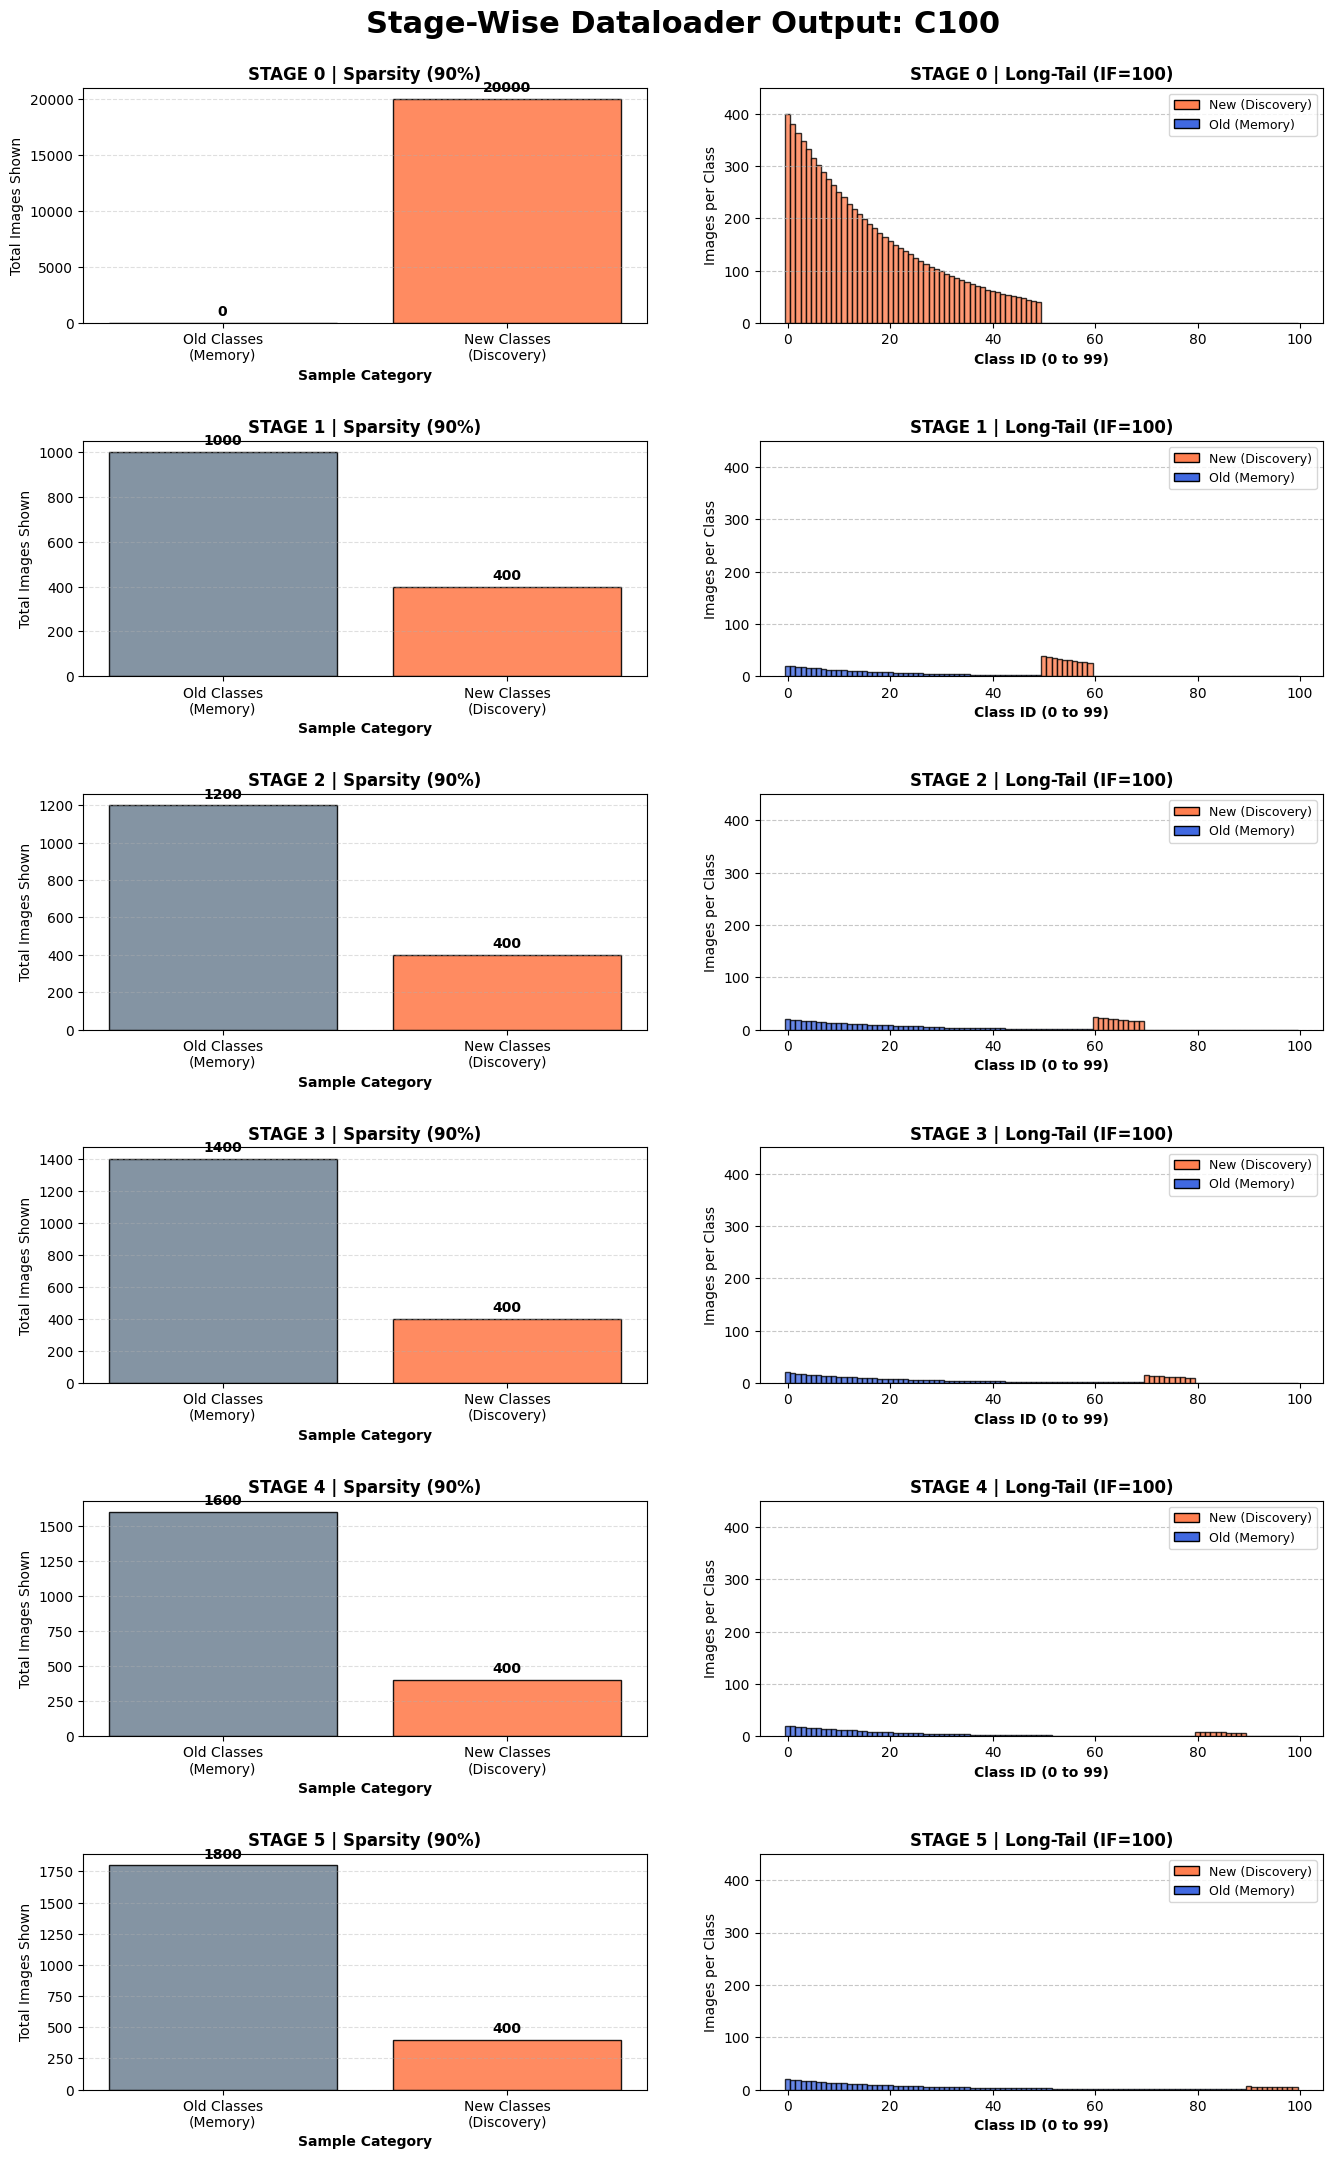

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from matplotlib.patches import Patch

def plot_stage_wise_distributions(dataset_name="C100", sparsity_val=0.90, if_val=100):
    """
    Plots a 6x2 grid. 
    Left: 2 Bars showing Total Old vs Total New samples.
    Right: 100 Bars showing class distribution, color-coded by Old vs New.
    """
    print(f"📊 Generating Custom Stage-Wise plots for {dataset_name.upper()}...")
    
    # We removed sharex=True because the left and right sides now have different X-axis types
    fig, axes = plt.subplots(6, 2, figsize=(16, 26))
    plt.subplots_adjust(hspace=0.5) # Increased space so X-axis labels fit nicely
    
    for stage in range(6):
        # ---------------------------------------------------------
        # 0. Figure out which classes are Old vs New for this stage
        # ---------------------------------------------------------
        # We instantiate a dummy dataset just to easily grab the class lists
        ds_dummy = CGCD_Master_Dataset(dataset_name, DATA_PATHS[dataset_name], stage=stage, setting="sparsity")
        
        if stage == 0:
            old_classes = []
            new_classes = ds_dummy.base_classes
        else:
            old_classes = ds_dummy.base_classes.copy()
            for s in range(1, stage):
                old_classes.extend(ds_dummy.novel_classes[s])
            new_classes = ds_dummy.novel_classes[stage]

        # ---------------------------------------------------------
        # 1. Sparsity Plot (Left): Just Two Bars (Total Old vs Total New)
        # ---------------------------------------------------------
        ds_sparse = CGCD_Master_Dataset(dataset_name, DATA_PATHS[dataset_name], stage=stage, setting="sparsity", sparsity_level=sparsity_val)
        counts_sparse = Counter([int(ds_sparse.all_targets[idx]) for idx in ds_sparse.final_indices])
        
        total_old_samples = sum(counts_sparse.get(c, 0) for c in old_classes)
        total_new_samples = sum(counts_sparse.get(c, 0) for c in new_classes)
        
        bars = axes[stage, 0].bar(
            ['Old Classes\n(Memory)', 'New Classes\n(Discovery)'], 
            [total_old_samples, total_new_samples], 
            color=['lightslategray', 'coral'], 
            edgecolor='black', alpha=0.9
        )
        axes[stage, 0].set_title(f"STAGE {stage} | Sparsity ({int(sparsity_val*100)}%)", fontweight='bold')
        axes[stage, 0].set_ylabel("Total Images Shown")
        axes[stage, 0].set_xlabel("Sample Category", fontsize=10, fontweight='bold') # X-axis defined per plot
        axes[stage, 0].grid(axis='y', linestyle='--', alpha=0.4)
        
        # Add the exact numbers on top of the bars
        axes[stage, 0].bar_label(bars, padding=3, fmt='%d', fontweight='bold', color='black')

        # ---------------------------------------------------------
        # 2. Long-Tail Plot (Right): Keep the Craft, Color by Category
        # ---------------------------------------------------------
        ds_lt = CGCD_Master_Dataset(dataset_name, DATA_PATHS[dataset_name], stage=stage, setting="long-tail", imbalance_factor=if_val)
        counts_lt = Counter([int(ds_lt.all_targets[idx]) for idx in ds_lt.final_indices])
        x_lt = range(100)
        y_lt = [counts_lt.get(c, 0) for c in x_lt]
        
        # Build a color list based on whether the class is Old or New
        colors_lt = []
        for c in x_lt:
            if c in new_classes:
                colors_lt.append('coral')       # Discovery classes get Coral
            elif c in old_classes:
                colors_lt.append('royalblue')   # Memory classes get Blue
            else:
                colors_lt.append('white')       # Future classes are invisible
        
        axes[stage, 1].bar(x_lt, y_lt, width=1.0, color=colors_lt, edgecolor='black', alpha=0.8)
        axes[stage, 1].set_title(f"STAGE {stage} | Long-Tail (IF={if_val})", fontweight='bold')
        axes[stage, 1].set_ylabel("Images per Class")
        axes[stage, 1].set_xlabel("Class ID (0 to 99)", fontsize=10, fontweight='bold') # X-axis defined per plot
        axes[stage, 1].set_ylim(0, 450)
        axes[stage, 1].grid(axis='y', linestyle='--', alpha=0.7)
        
        # Add a custom legend to the right-side plots to explain the colors
        legend_elements = [
            Patch(facecolor='coral', edgecolor='black', label='New (Discovery)'),
            Patch(facecolor='royalblue', edgecolor='black', label='Old (Memory)')
        ]
        axes[stage, 1].legend(handles=legend_elements, loc='upper right', fontsize=9)

    plt.suptitle(f"Stage-Wise Dataloader Output: {dataset_name.upper()}", fontsize=22, y=0.91, fontweight='bold')
    plt.show()

# Execute the plot
plot_stage_wise_distributions(dataset_name="C100", sparsity_val=0.90, if_val=100)

## CELL 4: Dataloader Wrapper

In [4]:
import torch
import torchvision.transforms as transforms
from PIL import Image

# ==============================================================================
# CELL 2: SINGLE-VIEW DATASET WRAPPER
# ==============================================================================
# Your method evaluates instances geometrically, so we only need 1 standard view
# instead of the 2 heavily augmented contrastive views Happy-CGCD uses.

class GeometricDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        real_idx = self.base_dataset.final_indices[idx]
        
        if self.base_dataset.dataset_name == "C100":
            image = self.base_dataset.image_paths_or_data[real_idx]
            image = Image.fromarray(image)
        else:
            img_path = self.base_dataset.image_paths_or_data[real_idx]
            image = Image.open(img_path).convert('RGB')
            
        label = self.base_dataset.all_targets[real_idx]
        image_t = self.transform(image)
        
        return image_t, label, real_idx

standard_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

print("✅ Geometric Dataset Wrapper Initialized!")

✅ Geometric Dataset Wrapper Initialized!


## CELL 5: Neural Architecture & Margin Losses

In [5]:
import torch.nn as nn
import torch.nn.functional as F

# ==============================================================================
# CELL 3: DINO ARCHITECTURE & YOUR GEOMETRIC LOSSES
# ==============================================================================

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim, use_bn=False, norm_last_layer=True, nlayers=3, hidden_dim=2048, bottleneck_dim=256):
        super().__init__()
        nlayers = max(nlayers, 1)
        if nlayers == 1:
            self.mlp = nn.Linear(in_dim, bottleneck_dim)
        else:
            layers = [nn.Linear(in_dim, hidden_dim)]
            if use_bn: layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.GELU())
            for _ in range(nlayers - 2):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                if use_bn: layers.append(nn.BatchNorm1d(hidden_dim))
                layers.append(nn.GELU())
            layers.append(nn.Linear(hidden_dim, bottleneck_dim))
            self.mlp = nn.Sequential(*layers)
        self.apply(self._init_weights)
        self.last_layer = nn.utils.weight_norm(nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
        if norm_last_layer:
            self.last_layer.weight_g.requires_grad = False

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x_proj = self.mlp(x)
        x_norm = nn.functional.normalize(x_proj, dim=-1, p=2)
        logits = self.last_layer(x_norm)
        return x_norm, logits

# --- YOUR LOSS FUNCTION ---
def margin_contrastive_loss(z, labels, pos_margin=0.85, neg_margin=0.1):
    sim = torch.matmul(z, z.T)
    mask = torch.eye(z.shape[0], dtype=torch.bool, device=z.device)
    labels_equal = (labels.unsqueeze(0) == labels.unsqueeze(1)) & ~mask
    labels_diff = ~labels_equal & ~mask
    pos_loss = F.relu(pos_margin - sim)[labels_equal].mean() if labels_equal.sum() > 0 else torch.tensor(0.0)
    neg_loss = F.relu(sim - neg_margin)[labels_diff].mean() if labels_diff.sum() > 0 else torch.tensor(0.0)
    return pos_loss + neg_loss

print("✅ Architecture & Losses Loaded!")

✅ Architecture & Losses Loaded!


## CELL 6: Memory Buffer & OOD Engine

In [6]:
import numpy as np
from collections import defaultdict

# ==============================================================================
# CELL 4: MEMORY HERDING & OOD DETECTION
# ==============================================================================

class MemoryBuffer:
    def __init__(self, max_per_class=400):
        self.data = defaultdict(list)
        self.max_per_class = max_per_class

    @torch.no_grad()
    def build_memory_herding(self, X_all, y_label, model, device):
        model.eval()
        logits_all, Z_all = [], []
        for i in range(0, len(X_all), 128):
            batch = X_all[i:i+128].to(device)
            z_norm, logits = model[1](model[0](batch)) # DINO -> Head
            logits_all.append(logits.cpu())
            Z_all.append(z_norm.cpu())
            
        logits_all = torch.cat(logits_all)
        Z_all = torch.cat(Z_all)
        class_mean = F.normalize(Z_all.mean(0), dim=0)
        selected_idx, features = [], Z_all.clone()

        for k in range(min(self.max_per_class, len(X_all))):
            if k > 0: S = Z_all[selected_idx].sum(0)
            else: S = torch.zeros_like(class_mean)
            target = (k + 1) * class_mean - S
            distances = torch.norm(features - target, dim=1)
            for idx in selected_idx: distances[idx] = float('inf')
            best = distances.argmin().item()
            selected_idx.append(best)

        self.data[int(y_label)] = []
        for idx in selected_idx:
            self.data[int(y_label)].append((X_all[idx].detach().cpu(), logits_all[idx].detach().cpu()))

    def sample_balanced(self, batch_size):
        classes = list(self.data.keys())
        if not classes: return None, None
        samples_per_class = max(1, batch_size // len(classes))
        X_mem, Y_mem = [], []
        for cls in classes:
            samples = self.data[cls]
            if not samples: continue
            replace = len(samples) < samples_per_class
            idx = np.random.choice(len(samples), samples_per_class, replace=replace)
            for i in idx:
                X_mem.append(samples[i][0])
                Y_mem.append(cls)
        if not X_mem: return None, None
        return torch.stack(X_mem), torch.tensor(Y_mem)

class HypersphereNovelty:
    def __init__(self, q=0.90):
        self.q = q
        self.mu, self.r = {}, {}

    def update(self, memory, model, device):
        self.mu, self.r = {}, {}
        for k, X_tuples in memory.data.items():
            if len(X_tuples) == 0: continue
            X = torch.stack([x for x, _ in X_tuples]).to(device)
            with torch.no_grad(): 
                z_norm, _ = model[1](model[0](X))
            mu = F.normalize(z_norm.mean(0), dim=0)
            d = 1 - torch.matmul(z_norm, mu)
            self.mu[k] = mu
            self.r[k] = torch.quantile(d, self.q)

    def score(self, z):
        if not self.mu: return torch.tensor(0.0)
        return min([(1 - torch.dot(z, self.mu[k].to(z.device))) - self.r[k].to(z.device) for k in self.mu])

print("✅ Memory & OOD Engines Loaded!")

✅ Memory & OOD Engines Loaded!


## CELL7: The "Evidence Accumulation" Pipeline

In [7]:
from torch.optim import SGD
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from collections import Counter
import scipy.spatial.distance as sp_dist

# ==============================================================================
# CELL 5: THE YOUR-METHOD PIPELINE (EVIDENCE-ACCUMULATION + DEEP DIAGNOSTICS)
# ==============================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---> 🎛️ THE MASTER EXECUTION TOGGLE 🎛️ <---
RUN_MODE = "1.5_HOUR_TEST" 
TARGET_DATASET = "C100" 

# 🎛️ THE ABLATION TOGGLE
DATASET_SETTING = "long-tail" # Options: "sparsity" or "long-tail"
SPARSITY_VAL = 0.90
IF_VAL = 100

# --- HUNGARIAN MATCHING ALGORITHM ---
def cluster_acc(y_true, y_pred, mask):
    from scipy.optimize import linear_sum_assignment
    y_true, y_pred, mask = y_true.astype(int), y_pred.astype(int), mask.astype(bool)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=int)
    for i in range(y_pred.size): w[y_pred[i], y_true[i]] += 1
    ind = np.vstack(linear_sum_assignment(w.max() - w)).T
    ind_map = {j: i for i, j in ind}
    
    total_acc = sum([w[i, j] for i, j in ind]) * 1.0 / y_pred.size
    
    old_classes_gt, new_classes_gt = set(y_true[mask]), set(y_true[~mask])
    old_acc, total_old = 0, 0
    for i in old_classes_gt:
        old_acc += w[ind_map[i], i] if i in ind_map else 0
        total_old += sum(w[:, i])
    old_acc = (old_acc / total_old) * 100 if total_old > 0 else 0.0

    new_acc, total_new = 0, 0
    for i in new_classes_gt:
        new_acc += w[ind_map[i], i] if i in ind_map else 0
        total_new += sum(w[:, i])
    new_acc = (new_acc / total_new) * 100 if total_new > 0 else 0.0
    return total_acc * 100, old_acc, new_acc

# --- THE NEW EVIDENCE PARAMETERS ---
ALPHA_DIST = 0.15          # Max intra-cluster cosine distance (Strict Proximity)
# PROMOTION_MIN_SIZE = 8     # Minimum cluster size required for promotion (Tolerates 90% Sparsity)
PROMOTION_MIN_SIZE = 4     # Minimum cluster size required for promotion (Tolerates 90% Sparsity)

DATASET_CONFIGS = {"C100": {"base": 50}, "IN100": {"base": 50}, "TINY": {"base": 100}, "CUB": {"base": 100}}
NUM_BASE_CLASSES = DATASET_CONFIGS[TARGET_DATASET]["base"]

# HARDCODED SPEEDRUN LIMITS (< 1.5 Hour Guarantee)
if RUN_MODE == "2_HOUR_TEST": 
    EPOCHS_OFFLINE, EPOCHS_ONLINE, MAX_BATCHES = 10, 5, 999999
elif RUN_MODE == "1.5_HOUR_TEST": 
    EPOCHS_OFFLINE, EPOCHS_ONLINE, MAX_BATCHES = 5, 2, 999999
elif RUN_MODE == "FAST_TEST": 
    EPOCHS_OFFLINE, EPOCHS_ONLINE, MAX_BATCHES = 1, 1, 3
else: 
    EPOCHS_OFFLINE, EPOCHS_ONLINE, MAX_BATCHES = 100, 30, 999999

# Init DINO
print("Initializing DINO ViT Backbone...")
backbone = torch.hub.load('facebookresearch/dino:main', 'dino_vitb16', verbose=False)
for m in backbone.parameters(): m.requires_grad = False
for name, m in backbone.named_parameters():
    if 'blocks.11' in name: m.requires_grad = True

model = nn.Sequential(backbone, DINOHead(in_dim=768, out_dim=NUM_BASE_CLASSES)).to(DEVICE)
memory = MemoryBuffer(max_per_class=100)
detector = HypersphereNovelty(q=0.95)

# DIAGNOSTIC LOGS
stage_metrics = {}
discovery_log = [] 
noise_log = []     
purity_log = []

print("\n" + "="*80)
print(f"🚀 STARTING YOUR GEOMETRIC OOD PIPELINE: EVIDENCE ACCUMULATION ({DATASET_SETTING.upper()})")
print(f"⚙️ Config Locked: Offline Epochs: {EPOCHS_OFFLINE} | Online Epochs: {EPOCHS_ONLINE}")
print("="*80)

for stage in range(6):
    print(f"\n---> INITIALIZING STAGE {stage} <---")
    
    # Initialize your custom data engine based on the master toggle
    if DATASET_SETTING == "sparsity":
        ds = CGCD_Master_Dataset(TARGET_DATASET, DATA_PATHS[TARGET_DATASET], stage=stage, setting="sparsity", sparsity_level=SPARSITY_VAL)
    else:
        ds = CGCD_Master_Dataset(TARGET_DATASET, DATA_PATHS[TARGET_DATASET], stage=stage, setting="long-tail", imbalance_factor=IF_VAL)
        
    loader = torch.utils.data.DataLoader(GeometricDatasetWrapper(ds, standard_transform), batch_size=128, drop_last=False, shuffle=True)

    if stage == 0:
        print("🎓 [STAGE 0] Training Base Classes...")
        model.train()
        opt = SGD([{'params': [p for p in model.parameters() if p.requires_grad]}], lr=0.1, momentum=0.9, weight_decay=5e-5)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_OFFLINE)
        
        for epoch in range(EPOCHS_OFFLINE):
            for b_idx, (x, y, _) in enumerate(loader):
                if b_idx >= MAX_BATCHES: break
                x, y = x.to(DEVICE), y.to(DEVICE)
                z_norm, logits = model[1](model[0](x))
                loss = F.cross_entropy(logits / 0.1, y) + margin_contrastive_loss(z_norm, y)
                opt.zero_grad(); loss.backward(); opt.step()
                if b_idx % 20 == 0: 
                    print(f"       -> Stage 0 | Epoch {epoch} | Batch {b_idx} | Loss: {loss.item():.4f} | LR: {sched.get_last_lr()[0]:.4f}")
            sched.step()
            
        print("💾 Building Herding Memory & Base Geometry...")
        class_buckets = {c: [] for c in range(NUM_BASE_CLASSES)}
        for b_idx, (x, y, _) in enumerate(loader):
            if b_idx >= MAX_BATCHES * 5: break 
            for i in range(len(y)):
                if len(class_buckets[y[i].item()]) < 100: class_buckets[y[i].item()].append(x[i])
                    
        for cls, x_list in class_buckets.items():
            if len(x_list) > 0: memory.build_memory_herding(torch.stack(x_list), cls, model, DEVICE)
        detector.update(memory, model, DEVICE)

    else:
        print(f"🔍 [STAGE {stage}] Geometric Evidence Accumulation...")
        model.eval()
        z_novel, x_novel, y_novel = [], [], []
        known_classes = model[1].last_layer.out_features
        
        # 1. ABSOLUTE OOD GATING
        with torch.no_grad():
            for x, y, _ in loader:
                x_dev = x.to(DEVICE)
                z_norm, _ = model[1](model[0](x_dev))
                for i in range(len(z_norm)):
                    score = detector.score(z_norm[i]).item()
                    if score > -0.05: 
                        z_novel.append(z_norm[i].cpu().numpy())
                        x_novel.append(x[i])
                        y_novel.append(y[i].item())
        
        if len(z_novel) >= PROMOTION_MIN_SIZE:
            Z = np.array(z_novel)
            
            # 2. PROXIMITY-BASED CLUSTERING
            clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=ALPHA_DIST, metric='cosine', linkage='average')
            cluster_labels = clustering.fit_predict(Z)
            
            counts = Counter(cluster_labels)
            for cid, count in counts.items():
                idxs = np.where(cluster_labels == cid)[0]
                
                if count < PROMOTION_MIN_SIZE:
                    noise_log.append(count)
                    continue
                
                labels_true = [y_novel[i] for i in idxs]
                most_common_cnt = Counter(labels_true).most_common(1)[0][1]
                cluster_purity = most_common_cnt / len(labels_true)
                
                cluster_mu = torch.from_numpy(Z[idxs].mean(0)).to(DEVICE)
                cluster_mu = F.normalize(cluster_mu, dim=0)
                
                # 3. PROTOTYPICAL HEAD INJECTION (FIXED DIMENSIONS & MLP RETENTION)
                new_label = known_classes
                known_classes += 1
                
                old_head = model[1]
                
                # The backbone output is 768. The bottleneck output is 256.
                new_head = DINOHead(in_dim=768, out_dim=known_classes).to(DEVICE)
                
                with torch.no_grad():
                    # CRITICAL FIX: Retain the MLP projection geometry
                    new_head.mlp.load_state_dict(old_head.mlp.state_dict())
                    
                    # DINOHead uses weight_norm, so we must map weight_v and weight_g explicitly
                    old_v = old_head.last_layer.weight_v.data
                    old_g = old_head.last_layer.weight_g.data
                    
                    new_head.last_layer.weight_v.data[:known_classes-1] = old_v
                    new_head.last_layer.weight_g.data[:known_classes-1] = old_g
                    
                    # Inject the new cluster prototype
                    new_head.last_layer.weight_v.data[known_classes-1] = cluster_mu
                    new_head.last_layer.weight_g.data[known_classes-1] = 1.0
                
                model[1] = new_head
                print(f"     🎉 [PROMOTION] Discovered New Class! Head expanded to {known_classes}.")
                
                # 4. TARGETED ONLINE ALIGNMENT
                model.train()
                for param in model[0].parameters(): param.requires_grad = False
                ft_opt = SGD(model[1].parameters(), lr=0.005, momentum=0.9)
                
                X_train = torch.stack([x_novel[i] for i in idxs]).to(DEVICE)
                Y_train = torch.full((len(idxs),), new_label, dtype=torch.long).to(DEVICE)
                
                for ft_epoch in range(EPOCHS_ONLINE):
                    X_mem, Y_mem = memory.sample_balanced(32)
                    if X_mem is not None:
                        bx, by = torch.cat([X_train, X_mem.to(DEVICE)]), torch.cat([Y_train, Y_mem.to(DEVICE)])
                    else: bx, by = X_train, Y_train
                        
                    z_norm, logits = model[1](model[0](bx))
                    loss = F.cross_entropy(logits / 0.1, by) + margin_contrastive_loss(z_norm, by)
                    ft_opt.zero_grad(); loss.backward(); ft_opt.step()
                    print(f"       -> Finetune Epoch {ft_epoch} | Loss: {loss.item():.4f}")
                
                # Log Diagnostics & Update Memory
                memory.build_memory_herding(X_train, new_label, model, DEVICE)
                detector.update(memory, model, DEVICE)
                discovery_log.append({'stage': stage, 'gt_labels': list(set(labels_true))})
                purity_log.append({'stage': stage, 'purity': cluster_purity, 'size': len(labels_true)})
                
        else:
            noise_log.append(len(z_novel))

    # --- EVALUATION ---
    print(f"📊 Evaluating Stage {stage} Accuracy...")
    model.eval()
    y_true, y_pred = [], []
    eval_indices = ds.final_indices[:200] if RUN_MODE == "FAST_TEST" else ds.final_indices
    
    with torch.no_grad():
        for idx in eval_indices:
            if ds.dataset_name == "C100": img = Image.fromarray(ds.image_paths_or_data[idx])
            else: img = Image.open(ds.image_paths_or_data[idx]).convert('RGB')
            img_t = standard_transform(img).unsqueeze(0).to(DEVICE)
            _, logits = model[1](model[0](img_t))
            y_true.append(ds.all_targets[idx])
            y_pred.append(logits.argmax(1).item())
            
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = np.isin(y_true, ds.base_classes)
    all_a, old_a, new_a = cluster_acc(y_true, y_pred, mask)
    stage_metrics[stage] = {'all': all_a, 'old': old_a, 'new': new_a}
    
    print(f"   => Stage {stage} Results: All: {all_a:.2f}% | Old: {old_a:.2f}% | New: {new_a:.2f}%")

# ==============================================================================
# FINAL OUTPUTS (EXACT ORIGINAL FORMATTING)
# ==============================================================================
print("\n" + "="*100)
print(f"{'TABLE 1: STAGE-WISE CONTINUAL GCD ACCURACY (YOUR METHOD)':^100}")
print("="*100)
t1_str = f"{'Ours (Geom)':<15} | {stage_metrics[0]['all']:.2f} (All) | "
for s in range(1, 6): t1_str += f"S{s}: {stage_metrics[s]['all']:.1f}/{stage_metrics[s]['old']:.1f}/{stage_metrics[s]['new']:.1f} | "
print(t1_str)

print("\n" + "="*50)
print(f"{'TABLE 3: FORGETTING & DISCOVERY':^50}")
print("="*50)
M_f = stage_metrics[0]['old'] - stage_metrics[5]['old']
M_d = stage_metrics[5]['new']
print(f"{'Method':<15} | {'M_f ↓ (Forget)':<15} | {'M_d ↑ (Discover)':<15}")
print(f"{'Ours (Geom)':<15} | {M_f:.2f}           | {M_d:.2f}")
print("="*50)

print("\n" + "🔥"*25)
print("   YOUR DEEP DIVE DIAGNOSTICS")
print("🔥"*25)
print(f"1. Total Noise Filtered (OOD Rejections): {sum(noise_log)} sparse samples safely ignored.")
print(f"2. Total Classes Discovered: {len(discovery_log)} classes promoted across 5 stages.")
print("3. Discovery & Purity Timeline:")
for d, p in zip(discovery_log, purity_log):
    print(f"   -> Stage {d['stage']}: Purity: {p['purity']:.2f} (Size: {p['size']}) | Ground Truth Semantics Found: {d['gt_labels']}")

Initializing DINO ViT Backbone...
Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_vitbase16_pretrain/dino_vitbase16_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_vitbase16_pretrain.pth


100%|██████████| 327M/327M [00:01<00:00, 328MB/s]



🚀 STARTING YOUR GEOMETRIC OOD PIPELINE: EVIDENCE ACCUMULATION (LONG-TAIL)
⚙️ Config Locked: Offline Epochs: 5 | Online Epochs: 2

---> INITIALIZING STAGE 0 <---
🎓 [STAGE 0] Training Base Classes...
       -> Stage 0 | Epoch 0 | Batch 0 | Loss: 4.7248 | LR: 0.1000
       -> Stage 0 | Epoch 0 | Batch 20 | Loss: 1.2757 | LR: 0.1000
       -> Stage 0 | Epoch 0 | Batch 40 | Loss: 1.4065 | LR: 0.1000
       -> Stage 0 | Epoch 0 | Batch 60 | Loss: 1.1492 | LR: 0.1000
       -> Stage 0 | Epoch 1 | Batch 0 | Loss: 0.6897 | LR: 0.0905
       -> Stage 0 | Epoch 1 | Batch 20 | Loss: 0.5726 | LR: 0.0905
       -> Stage 0 | Epoch 1 | Batch 40 | Loss: 0.8141 | LR: 0.0905
       -> Stage 0 | Epoch 1 | Batch 60 | Loss: 0.7358 | LR: 0.0905
       -> Stage 0 | Epoch 2 | Batch 0 | Loss: 0.6622 | LR: 0.0655
       -> Stage 0 | Epoch 2 | Batch 20 | Loss: 0.4028 | LR: 0.0655
       -> Stage 0 | Epoch 2 | Batch 40 | Loss: 0.3392 | LR: 0.0655
       -> Stage 0 | Epoch 2 | Batch 60 | Loss: 0.3669 | LR: 0.0655
